# Next-Activity Prediction: CASAS hh101
**DA331 Big Data Analytics, Assignment 5 (Task 2)**
**Kumar Utkarsh (240150016)**

**Task.** When an activity ends, predict which activity the resident performs next.

**Pipeline**
1. Load the labelled event stream and expand the `begin`/`end` annotations to per-event labels
2. Convert events into activity **episodes** (one per annotated segment, `Other` removed)
3. Build **temporal features** for each episode *t*; the target is the activity of episode *t+1*
4. **Chronological split**: first 70% train, next 15% validation, last 15% test
5. Models: majority class, Markov chains (1st order, 2nd order, time-aware) and a gradient-boosted tree
   classifier on the temporal features
6. Evaluate with accuracy, macro-F1 and top-3 accuracy, then look at per-class errors and feature importance

In [1]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 160)

BASE = Path("/kaggle/input") if Path("/kaggle/input").exists() else Path("data")
LAB = next(BASE.rglob("labeled/hh101.csv"))
OUT = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("outputs")
FIG = Path("figures")
OUT.mkdir(exist_ok=True); FIG.mkdir(exist_ok=True)
SEED = 42
N_LAGS = 3
MIN_EPISODES = 20

## 1. Data and episodes

In [2]:
def load_labeled(path):
    df = pd.read_csv(path, header=None, names=["date", "time", "sensor", "message", "label"])
    df["timestamp"] = pd.to_datetime(df["date"] + " " + df["time"], format="ISO8601")
    m = df["label"].str.extract(r'^(\w+)(?:="(begin|end)")?$')
    name, mark = m[0], m[1]
    state = pd.Series(np.select([mark.eq("begin"), mark.eq("end")], [name, "<end>"], ""), index=df.index)
    state = state.replace("", np.nan).ffill()
    inside = state.notna() & state.ne("<end>")
    df["activity"] = np.where(mark.eq("end"), name, np.where(inside, state, name.fillna("Other")))
    df = df.sort_values("timestamp", kind="stable").reset_index(drop=True)
    return df[["timestamp", "sensor", "message", "activity"]].astype(
        {"sensor": "category", "message": "category", "activity": "category"})



def build_episodes(df, merge_gap_min=1):
    a = df.activity.astype(str)
    run = (a != a.shift()).cumsum()
    ep = df.assign(activity=a).groupby(run).agg(
        activity=("activity", "first"), start=("timestamp", "first"), end=("timestamp", "last"),
        n_events=("timestamp", "size"), last_sensor=("sensor", "last"))
    ep = ep[ep.activity != "Other"].reset_index(drop=True)
    gap = (ep.start - ep.end.shift()).dt.total_seconds() / 60
    new = (ep.activity != ep.activity.shift()) | (gap > merge_gap_min)
    ep = ep.groupby(new.cumsum()).agg(
        activity=("activity", "first"), start=("start", "first"), end=("end", "last"),
        n_events=("n_events", "sum"), last_sensor=("last_sensor", "last"))
    ep["duration_min"] = (ep.end - ep.start).dt.total_seconds() / 60
    return ep.reset_index(drop=True)


lab = load_labeled(LAB)
ep = build_episodes(lab)
print(f"{len(lab):,} events -> {len(ep):,} episodes, {ep.activity.nunique()} activities")
ep.head()

222,858 events -> 2,677 episodes, 34 activities


,activity,start,end,n_events,last_sensor,duration_min
0,Step_Out,2012-07-20 10:38:54.512364,2012-07-20 10:50:54.933393,42,OutsideDoor,12.007017
1,Toilet,2012-07-20 11:09:18.952300,2012-07-20 11:10:09.432254,18,Bathroom,0.841333
2,Phone,2012-07-20 11:50:04.029817,2012-07-20 11:55:40.958827,26,LivingRoom,5.615483
3,Personal_Hygiene,2012-07-20 12:00:43.445554,2012-07-20 12:05:37.240999,104,Bathroom,4.896591
4,Leave_Home,2012-07-20 12:06:43.637047,2012-07-20 12:06:58.769302,14,OutsideDoor,0.252204


Labels with fewer than 20 episodes (e.g. `Entertain_Guests`, `Wash_Lunch_Dishes`) are too rare
to learn from a 60-day log, so they are merged into a single `Rare` class.

In [3]:
counts = ep.activity.value_counts()
rare = counts[counts < MIN_EPISODES].index
ep["activity"] = ep.activity.where(~ep.activity.isin(rare), "Rare")
print("merged into Rare:", list(rare))
ep.activity.value_counts().to_frame("episodes").T

merged into Rare: ['Bed_Toilet_Transition', 'Cook', 'Eat', 'Cook_Lunch', 'Wash_Dinner_Dishes', 'Eat_Lunch', 'Wash_Lunch_Dishes', 'Entertain_Guests', 'Work_At_Table']


activity,Toilet,Watch_TV,Sleep_Out_Of_Bed,Personal_Hygiene,Dress,Leave_Home,Enter_Home,Rare,Read,Relax,...,Eat_Breakfast,Wake_Up,Morning_Meds,Bathe,Step_Out,Groom,Cook_Dinner,Wash_Breakfast_Dishes,Wash_Dishes,Eat_Dinner
episodes,360,319,198,178,175,171,170,111,87,75,...,58,57,57,55,50,33,33,31,28,21


## 2. Temporal features
Every feature is known when episode *t* ends, so the model never sees the future.

| feature | meaning |
|---|---|
| `cur_act`, `prev1..3_act` | current activity and the three before it |
| `hour_sin`, `hour_cos` | time of day at the end of the episode (cyclic encoding) |
| `dow`, `is_weekend` | day of week |
| `log_duration`, `log_n_events` | length of the current episode |
| `last_sensor` | room of the last sensor event |
| `log_gap_prev` | idle time since the previous episode |

In [4]:
def make_features(ep):
    X = pd.DataFrame({"cur_act": ep.activity})
    for k in range(1, N_LAGS + 1):
        X[f"prev{k}_act"] = ep.activity.shift(k).fillna("<start>")
    h = ep.end.dt.hour + ep.end.dt.minute / 60
    X["hour"] = h
    X["hour_sin"], X["hour_cos"] = np.sin(2 * np.pi * h / 24), np.cos(2 * np.pi * h / 24)
    X["dow"] = ep.end.dt.dayofweek
    X["is_weekend"] = (X.dow >= 5).astype(int)
    X["log_duration"] = np.log1p(ep.duration_min)
    X["log_n_events"] = np.log1p(ep.n_events)
    X["last_sensor"] = ep.last_sensor.astype(str)
    X["log_gap_prev"] = np.log1p((ep.start - ep.end.shift()).dt.total_seconds().fillna(0).clip(lower=0) / 60)
    y = ep.activity.shift(-1)
    keep = y.notna()
    return X[keep].reset_index(drop=True), y[keep].reset_index(drop=True), ep.end[keep].reset_index(drop=True)

X, y, t_end = make_features(ep)
print(X.shape)
X.head()

(2676, 13)


,cur_act,prev1_act,prev2_act,prev3_act,hour,hour_sin,hour_cos,dow,is_weekend,log_duration,log_n_events,last_sensor,log_gap_prev
0,Step_Out,<start>,<start>,<start>,10.833333,0.300706,-0.953717,4,0,2.565489,3.761200,OutsideDoor,0.000000
1,Toilet,Step_Out,<start>,<start>,11.166667,0.216440,-0.976296,4,0,0.610490,2.944439,Bathroom,2.965289
2,Phone,Toilet,Step_Out,<start>,11.916667,0.021815,-0.999762,4,0,1.889413,3.295837,LivingRoom,3.711374
3,Personal_Hygiene,Phone,Toilet,Step_Out,12.083333,-0.021815,-0.999762,4,0,1.774374,4.653960,Bathroom,1.798643
4,Leave_Home,Personal_Hygiene,Phone,Toilet,12.100000,-0.026177,-0.999657,4,0,0.224905,2.708050,OutsideDoor,0.745076


In [5]:
n = len(X)
i_tr, i_va = int(0.70 * n), int(0.85 * n)
idx = {"train": np.arange(i_tr), "val": np.arange(i_tr, i_va), "test": np.arange(i_va, n)}
for k, i in idx.items():
    print(f"{k:5s} {len(i):5d} samples  {t_end[i[0]]:%Y-%m-%d} -> {t_end[i[-1]]:%Y-%m-%d}")

CLASSES = np.array(sorted(y.unique()))
yi = y.map({c: i for i, c in enumerate(CLASSES)}).to_numpy()
ytr, yva, yte = yi[idx["train"]], yi[idx["val"]], yi[idx["test"]]
Xtr, Xva, Xte = X.iloc[idx["train"]], X.iloc[idx["val"]], X.iloc[idx["test"]]

train  1873 samples  2012-07-20 -> 2012-09-01
val     401 samples  2012-09-01 -> 2012-09-09
test    402 samples  2012-09-09 -> 2012-09-17


## 3. Baselines: Markov chains
P(next | context) is estimated from transition counts with add-α smoothing. When a context never
occurred in training, the model backs off to a shorter one.

In [6]:
class Markov:
    def __init__(self, context, alpha=0.1):
        self.context, self.alpha = context, alpha

    def _key(self, X, cols):
        return X[cols].astype(str).agg("|".join, axis=1) if cols else pd.Series("", index=X.index)

    def fit(self, X, y):
        self.tables = [(self.context[:j], pd.crosstab(self._key(X, self.context[:j]), y)
                        .reindex(columns=range(len(CLASSES)), fill_value=0))
                       for j in range(len(self.context), -1, -1)]
        return self

    def predict_proba(self, X):
        P, done = np.zeros((len(X), len(CLASSES))), np.zeros(len(X), bool)
        for cols, cnt in self.tables:
            key = self._key(X, cols)
            hit = key.isin(cnt.index).to_numpy() & ~done
            if hit.any():
                c = cnt.loc[key[hit]].to_numpy() + self.alpha
                P[hit] = c / c.sum(axis=1, keepdims=True)
                done |= hit
        return P


def scores(P, y_true):
    pred = P.argmax(1)
    top3 = np.argsort(-P, axis=1)[:, :3]
    return {"accuracy": accuracy_score(y_true, pred),
            "macro_f1": f1_score(y_true, pred, average="macro", labels=np.unique(y_true), zero_division=0),
            "weighted_f1": f1_score(y_true, pred, average="weighted", zero_division=0),
            "top3_acc": np.mean([t in r for t, r in zip(y_true, top3)])}


with_bin = lambda X: X.assign(hour_bin=(X.hour // 3).astype(int))
markov = {
    "Majority class": Markov([]),
    "Markov-1: P(next | cur)": Markov(["cur_act"]),
    "Markov-2: P(next | prev, cur)": Markov(["cur_act", "prev1_act"]),
    "Time-aware Markov: P(next | cur, 3h bin)": Markov(["cur_act", "hour_bin"]),
}
val_res = {name: scores(m.fit(with_bin(Xtr), ytr).predict_proba(with_bin(Xva)), yva) for name, m in markov.items()}
pd.DataFrame(val_res).T.round(3)

,accuracy,macro_f1,weighted_f1,top3_acc
Majority class,0.115,0.008,0.024,0.279
Markov-1: P(next | cur),0.337,0.258,0.272,0.551
"Markov-2: P(next | prev, cur)",0.409,0.391,0.384,0.576
"Time-aware Markov: P(next | cur, 3h bin)",0.426,0.358,0.387,0.648


## 4. Gradient-boosted trees on temporal features
`HistGradientBoostingClassifier` handles the categorical lags natively and mixes them with the cyclic
time features. Three configurations are compared on the validation period. The best one is then
refit on train+validation and evaluated once on the test period.

In [7]:
CAT = ["cur_act"] + [f"prev{k}_act" for k in range(1, N_LAGS + 1)] + ["last_sensor"]
NUM = ["hour_sin", "hour_cos", "dow", "is_weekend", "log_duration", "log_n_events", "log_gap_prev"]
FEATURES = CAT + NUM


def fit_encoder(X):
    return {c: {v: i for i, v in enumerate(sorted(X[c].unique()))} for c in CAT}


def encode(X, enc):
    Z = X[FEATURES].copy()
    for c in CAT:
        Z[c] = Z[c].map(enc[c]).fillna(len(enc[c]))
    return Z.astype(float)


def hgb(**params):
    return HistGradientBoostingClassifier(categorical_features=[f in CAT for f in FEATURES], max_iter=300,
                                          early_stopping=True, validation_fraction=0.15, n_iter_no_change=20,
                                          random_state=SEED, **params)


def proba(model, Z):
    P = np.zeros((len(Z), len(CLASSES)))
    P[:, model.classes_] = model.predict_proba(Z)
    return P


enc = fit_encoder(Xtr)
grid = [dict(learning_rate=0.1, max_leaf_nodes=15, l2_regularization=1.0),
        dict(learning_rate=0.05, max_leaf_nodes=31, l2_regularization=1.0),
        dict(learning_rate=0.05, max_leaf_nodes=15, l2_regularization=1.0, class_weight="balanced")]
rows = []
for g in grid:
    t0 = time.time()
    m = hgb(**g).fit(encode(Xtr, enc), ytr)
    rows.append({**{"params": str(g)}, **scores(proba(m, encode(Xva, enc)), yva), "iters": m.n_iter_,
                 "sec": round(time.time() - t0, 1)})
grid_res = pd.DataFrame(rows)
best = grid[int((grid_res.accuracy + grid_res.macro_f1).idxmax())]
print("best:", best)
grid_res.round(3)

best: {'learning_rate': 0.05, 'max_leaf_nodes': 31, 'l2_regularization': 1.0}


,params,accuracy,macro_f1,weighted_f1,top3_acc,iters,sec
0,"{'learning_rate': 0.1, 'max_leaf_nodes': 15, '...",0.406,0.425,0.394,0.668,40,1.0
1,"{'learning_rate': 0.05, 'max_leaf_nodes': 31, ...",0.429,0.442,0.413,0.671,65,1.7
2,"{'learning_rate': 0.05, 'max_leaf_nodes': 15, ...",0.416,0.452,0.408,0.688,55,2.6


## 5. Test-set comparison

In [8]:
trva = np.concatenate([idx["train"], idx["val"]])
Xtv, ytv = X.iloc[trva], yi[trva]
enc = fit_encoder(Xtv)
model = hgb(**best).fit(encode(Xtv, enc), ytv)

P_test = {name: m.fit(with_bin(Xtv), ytv).predict_proba(with_bin(Xte)) for name, m in markov.items()}
P_test["Gradient boosting (temporal features)"] = proba(model, encode(Xte, enc))
results = pd.DataFrame({k: scores(P, yte) for k, P in P_test.items()}).T
results.round(3)

,accuracy,macro_f1,weighted_f1,top3_acc
Majority class,0.102,0.007,0.019,0.259
Markov-1: P(next | cur),0.343,0.263,0.282,0.609
"Markov-2: P(next | prev, cur)",0.415,0.400,0.391,0.644
"Time-aware Markov: P(next | cur, 3h bin)",0.428,0.385,0.396,0.659
Gradient boosting (temporal features),0.460,0.465,0.446,0.692


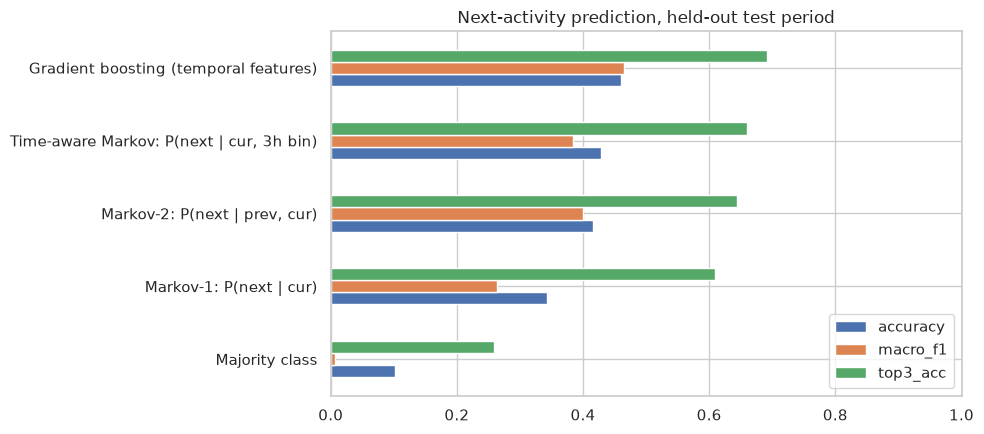

In [9]:
ax = results[["accuracy", "macro_f1", "top3_acc"]].plot.barh(figsize=(10, 4.5), xlim=(0, 1))
ax.set_title("Next-activity prediction, held-out test period"); ax.legend(loc="lower right")
plt.tight_layout(); plt.savefig(FIG / "model_results.png", dpi=110); plt.show()

## 6. Error analysis

In [10]:
pred = P_test["Gradient boosting (temporal features)"].argmax(1)
present = np.unique(np.concatenate([yte, pred]))
print(classification_report(yte, pred, labels=present, target_names=CLASSES[present], zero_division=0, digits=3))

                       precision    recall  f1-score   support

                Bathe      0.500     0.333     0.400         9
       Cook_Breakfast      0.778     0.778     0.778         9
          Cook_Dinner      1.000     0.250     0.400         4
                Dress      0.600     0.469     0.526        32
                Drink      0.000     0.000     0.000        13
        Eat_Breakfast      0.778     0.875     0.824         8
           Eat_Dinner      0.667     0.667     0.667         3
           Enter_Home      1.000     1.000     1.000        25
         Evening_Meds      0.273     0.333     0.300         9
          Go_To_Sleep      0.417     0.714     0.526         7
                Groom      1.000     0.333     0.500         6
           Leave_Home      0.265     0.360     0.305        25
         Morning_Meds      0.750     0.750     0.750         8
     Personal_Hygiene      0.500     0.200     0.286        35
                Phone      0.333     0.053     0.091  

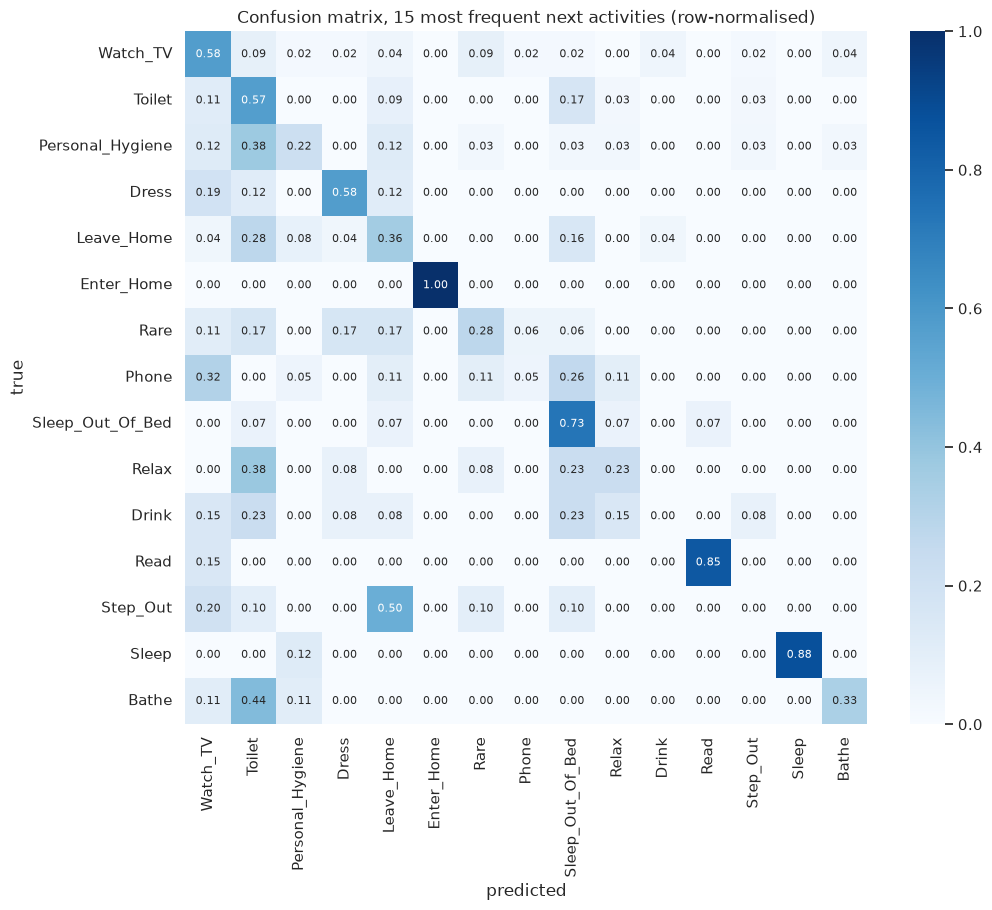

In [11]:
top = pd.Series(yte).value_counts().index[:15].to_numpy()
cm = confusion_matrix(yte, pred, labels=top, normalize="true")
plt.figure(figsize=(11, 9))
sns.heatmap(cm, xticklabels=CLASSES[top], yticklabels=CLASSES[top], cmap="Blues", annot=True, fmt=".2f",
            annot_kws={"size": 8})
plt.title("Confusion matrix, 15 most frequent next activities (row-normalised)")
plt.xlabel("predicted"); plt.ylabel("true")
plt.savefig(FIG / "model_confusion.png", dpi=110, bbox_inches="tight"); plt.show()

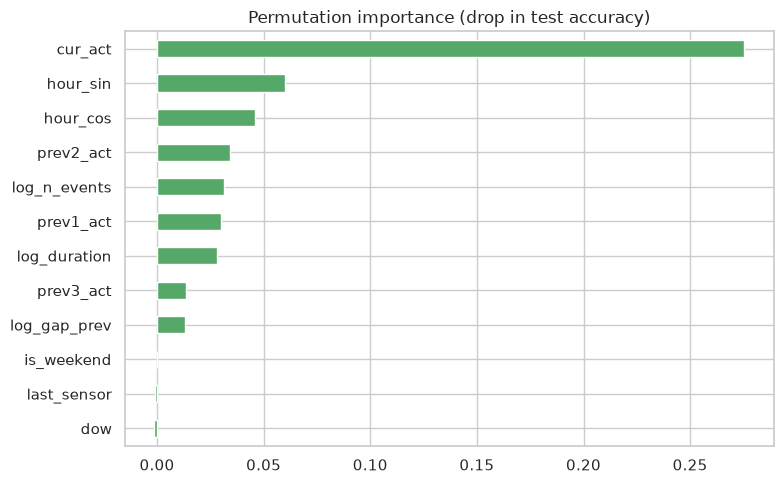

In [12]:
pi = permutation_importance(model, encode(Xte, enc), yte, n_repeats=20, random_state=SEED, scoring="accuracy")
imp = pd.Series(pi.importances_mean, index=FEATURES).sort_values()
imp.plot.barh(figsize=(8, 5), color="C2", title="Permutation importance (drop in test accuracy)")
plt.tight_layout(); plt.savefig(FIG / "model_importance.png", dpi=110); plt.show()

In [13]:
hour_acc = pd.Series(pred == yte).groupby((Xte.hour.to_numpy() // 3 * 3).astype(int)).agg(["mean", "size"])
hour_acc.columns = ["accuracy", "samples"]
hour_acc.index = [f"{h:02d}-{h+3:02d}h" for h in hour_acc.index]
hour_acc.round(3).T

,00-03h,03-06h,06-09h,09-12h,12-15h,15-18h,18-21h,21-24h
accuracy,0.476,0.417,0.721,0.397,0.41,0.41,0.441,0.404
samples,21.000,12.000,61.000,78.000,78.00,61.00,34.000,57.000


## 7. Saving the model and example predictions

In [14]:
bundle = {"model": model, "encoder": enc, "features": FEATURES, "classes": CLASSES}
joblib.dump(bundle, OUT / "next_activity_model.joblib")
results.round(4).to_csv(OUT / "results.csv")


def predict_next(history, k=3):
    Xh, _, _ = make_features(pd.concat([history, history.tail(1)], ignore_index=True))
    p = proba(bundle["model"], encode(Xh.tail(1), bundle["encoder"]))[0]
    return [(str(CLASSES[i]), round(float(p[i]), 2)) for i in np.argsort(-p)[:k]]


start = len(ep) - 12
for i in range(start, start + 10):
    h = ep.iloc[: i + 1]
    print(f"{h.end.iloc[-1]:%m-%d %H:%M}  {h.activity.iloc[-1]:<18s} -> {predict_next(h)}   actual: {ep.activity.iloc[i + 1]}")

09-17 19:57  Personal_Hygiene   -> [('Dress', 0.56), ('Toilet', 0.09), ('Evening_Meds', 0.07)]   actual: Rare
09-17 20:02  Rare               -> [('Watch_TV', 0.45), ('Rare', 0.21), ('Sleep', 0.07)]   actual: Rare
09-17 20:11  Rare               -> [('Watch_TV', 0.83), ('Rare', 0.11), ('Evening_Meds', 0.01)]   actual: Watch_TV
09-17 22:29  Watch_TV           -> [('Evening_Meds', 0.54), ('Toilet', 0.25), ('Drink', 0.04)]   actual: Wash_Dishes
09-17 22:32  Wash_Dishes        -> [('Sleep_Out_Of_Bed', 0.38), ('Evening_Meds', 0.28), ('Watch_TV', 0.13)]   actual: Phone
09-17 22:39  Phone              -> [('Wash_Dishes', 0.41), ('Watch_TV', 0.24), ('Dress', 0.11)]   actual: Dress


09-17 22:56  Dress              -> [('Evening_Meds', 0.4), ('Toilet', 0.18), ('Personal_Hygiene', 0.11)]   actual: Toilet
09-17 22:56  Toilet             -> [('Dress', 0.48), ('Watch_TV', 0.23), ('Evening_Meds', 0.06)]   actual: Evening_Meds
09-17 22:57  Evening_Meds       -> [('Watch_TV', 0.71), ('Dress', 0.06), ('Sleep_Out_Of_Bed', 0.04)]   actual: Dress
09-17 23:06  Dress              -> [('Personal_Hygiene', 0.24), ('Toilet', 0.22), ('Evening_Meds', 0.21)]   actual: Personal_Hygiene


## 8. Summary

In [15]:
b = results.loc["Gradient boosting (temporal features)"]
m1 = results.loc["Markov-1: P(next | cur)"]
print(f"episodes {len(ep)}, classes {len(CLASSES)}, train+val {len(trva)}, test {len(idx['test'])}")
print(f"Markov-1          acc {m1.accuracy:.3f}  macro-F1 {m1.macro_f1:.3f}  top-3 {m1.top3_acc:.3f}")
print(f"Gradient boosting acc {b.accuracy:.3f}  macro-F1 {b.macro_f1:.3f}  top-3 {b.top3_acc:.3f}")
print("most important features:", ", ".join(imp.sort_values(ascending=False).index[:4]))

episodes 2677, classes 26, train+val 2274, test 402
Markov-1          acc 0.343  macro-F1 0.263  top-3 0.609
Gradient boosting acc 0.460  macro-F1 0.465  top-3 0.692
most important features: cur_act, hour_sin, hour_cos, prev2_act


### Conclusions
* The chronological test period (the last 8 days, 402 transitions over 26 classes) is scored against a
  majority baseline of 10% accuracy.
* A first-order Markov chain reaches **34%** accuracy. Adding one more step of history (Markov-2, 42%) or
  the time of day (time-aware Markov, 43%) each helps, as the EDA entropy analysis predicted.
* Gradient boosting on the temporal features reaches the best scores: **46% accuracy, 0.47 macro-F1 and
  69% top-3 accuracy**.
* The most important features are the current activity and the time of day (`hour_sin`/`hour_cos`),
  followed by earlier activities.
* Routine transitions are predicted well: *Enter_Home* (F1 1.00), *Read*, *Eat_Breakfast*, *Sleep* and
  *Wake_Up* (F1 ≥ 0.82).
* Errors are concentrated in short, frequent "filler" activities that can follow almost anything
  (*Toilet*, *Phone*, *Drink*, *Personal_Hygiene*), and in the merged `Rare` class. Accuracy is highest in
  the structured morning routine (72% at 06–09h).
* **Limitations and next steps:** the model is trained on one home and only 60 days of labels. Possible
  next steps are sequence models (GRU/Transformer) over episodes, semi-supervised use of the
  10 unlabelled months, and predicting *when* the next activity starts.